In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.9/753.9 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.4 MB/s eta 0:00:00


In [ ]:
import mlflow

In [ ]:
import mlflow

# Set your MLflow tracking server
mlflow.set_tracking_uri("http://ec2-3-80-151-84.compute-1.amazonaws.com:5000")

# Start a test run
with mlflow.start_run():
    mlflow.log_param("param1", 5)
    mlflow.log_metric("metric1", 0.89)

print("✅ Test run logged successfully!")


🏃 View run blushing-grub-868 at: http://ec2-3-80-151-84.compute-1.amazonaws.com:5000/#/experiments/0/runs/ec05e50d99f642dfb3922bd1c1f9c9cc
🧪 View experiment at: http://ec2-3-80-151-84.compute-1.amazonaws.com:5000/#/experiments/0
✅ Test run logged successfully!


In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df= pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')

In [ ]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [ ]:
df.dropna(inplace= True)

In [ ]:
df.drop_duplicates(inplace= True)

In [ ]:
df = df[df['clean_comment'].str.strip() != '']


In [ ]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [ ]:
!pip install nltk

In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Define the preprocessing function
def preprocess_comment(comment):

    # Convert to lowercase
    comment = comment.lower()

    # Remove leading and trailing spaces
    comment = comment.strip()

    # Remove newline characters
    comment = re.sub(r'\n', ' ', comment)

    # Remove special characters (keep only letters and numbers)
    comment = re.sub(r'[^a-zA-Z0-9 ]', '', comment)

    # Remove stopwords but keep important sentiment words
    stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}
    comment = " ".join(word for word in comment.split() if word not in stop_words)

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    comment = " ".join(lemmatizer.lemmatize(word) for word in comment.split())

    return comment


In [ ]:
df['clean_comment']= df['clean_comment'].apply(preprocess_comment)

In [ ]:
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.to_csv('cleaned_data.csv', index= False)

In [ ]:
df.to_csv('/content/drive/MyDrive/cleaned_data.csv', index=False)


In [ ]:
df.to_csv('cleaned_data.csv', index= False)

In [ ]:
pd.read_csv('cleaned_data.csv').head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Step 1: Vectorize the comments using Bag of Words (CountVectorizer)
vectorizer = CountVectorizer(max_features=1000)  # Bag of Words model with a limit of 1000 features

X = vectorizer.fit_transform(df['clean_comment']).toarray()
y = df['category']  # Assuming 'category' is the target variable (0 or 1 for binary classification)




In [ ]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
y

,category
0,1
1,1
2,-1
3,0
4,1
...,...
37244,0
37245,1
37246,0
37247,1


In [ ]:
mlflow.set_tracking_uri("http://ec2-3-80-151-84.compute-1.amazonaws.com:5000")

In [ ]:
!pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.1 MB/s eta 0:00:00


In [ ]:
[REDACTED_AWS_ACCESS_KEY_ID]

[REDACTED_AWS_SECRET_ACCESS_KEY]

NameError: name '[REDACTED_AWS_ACCESS_KEY_ID]' is not defined

In [ ]:
!pip install awscli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 30.5 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [ ]:
!aws configure

AWS Access Key ID [None]: [REDACTED_AWS_ACCESS_KEY_ID]
AWS Secret Access Key [None]: [REDACTED_AWS_SECRET_ACCESS_KEY]
Default region name [None]: us-east-1
Default output format [None]: 


In [ ]:
# ========= Core Libraries =========
import pandas as pd
import numpy as np

# ========= Text Preprocessing =========
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ========= Machine Learning =========
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ========= MLflow =========
import mlflow
import mlflow.sklearn

# ========= Visualization =========
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
mlflow.set_tracking_uri("http://ec2-3-80-151-84.compute-1.amazonaws.com:5000")

In [ ]:
mlflow.set_experiment("youtube_sentiment_baseline1")

2025/12/09 15:16:35 INFO mlflow.tracking.fluent: Experiment with name 'youtube_sentiment_baseline1' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://ytcommentproj/710185475288632044', creation_time=1765293395774, experiment_id='710185475288632044', last_update_time=1765293395774, lifecycle_stage='active', name='youtube_sentiment_baseline1', tags={}>

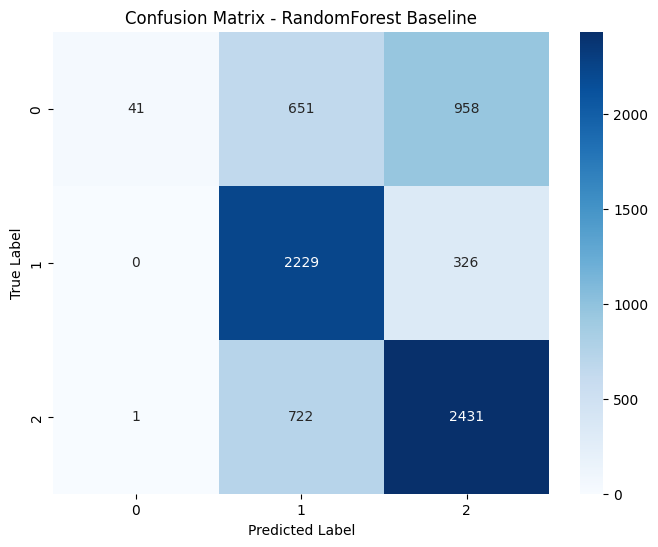

✅ Accuracy: 0.6388096208724011
🏃 View run RandomForest_Baseline_Train_Test_Split at: http://ec2-3-80-151-84.compute-1.amazonaws.com:5000/#/experiments/710185475288632044/runs/1632fac309c44a10bfce6bc36d2e21db
🧪 View experiment at: http://ec2-3-80-151-84.compute-1.amazonaws.com:5000/#/experiments/710185475288632044


In [ ]:
# Step 1: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Define and train a Random Forest baseline model using a simple train-test split
with mlflow.start_run() as run:

    # Log a description for the run
    mlflow.set_tag("mlflow.runName", "RandomForest_Baseline_Train_Test_Split")
    mlflow.set_tag("experiment_type", "baseline")
    mlflow.set_tag("model_type", "RandomForestClassifier")

    # Add a description
    mlflow.set_tag(
        "description",
        "Baseline RandomForest model for sentiment analysis using Bag of Words (BoW) with a simple train-test split"
    )

    # Log parameters for the vectorizer
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    # Log Random Forest parameters
    n_estimators = 100
    max_depth = 10

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    # Initialize and train the model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Log accuracy
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    # Log classification report metrics
    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - RandomForest Baseline")
    plt.show()

    print("✅ Accuracy:", accuracy)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict on test data
y_pred = model.predict(X_test)

# Print classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Optional: print accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Optional: confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

          -1       0.98      0.02      0.05      1650
           0       0.62      0.87      0.72      2555
           1       0.65      0.77      0.71      3154

    accuracy                           0.64      7359
   macro avg       0.75      0.56      0.49      7359
weighted avg       0.71      0.64      0.57      7359

Accuracy: 0.6388096208724011

Confusion Matrix:

[[  41  651  958]
 [   0 2229  326]
 [   1  722 2431]]
